공공데이터포털에서 공휴일 데이터를 수집 중입니다...
참고: 날짜 컬럼이 없어 Oworld.csv에 이미 존재하는 'holiday' 컬럼을 유지합니다.
정규화 적용된 피처: ['temperature', 'humidity', 'rain']
최종 전처리 파일 저장 완료: Oworld_final_processed.csv

[피처 간 상관관계 분석 결과]
              holiday   weekend       mon       tue       wed      thur  \
holiday      1.000000  0.936739 -0.232847 -0.232847 -0.251185 -0.241526   
weekend      0.936739  1.000000 -0.258741 -0.258741 -0.257916 -0.257916   
mon         -0.232847 -0.258741  1.000000 -0.167276 -0.166742 -0.166742   
tue         -0.232847 -0.258741 -0.167276  1.000000 -0.166742 -0.166742   
wed         -0.251185 -0.257916 -0.166742 -0.166742  1.000000 -0.166210   
thur        -0.241526 -0.257916 -0.166742 -0.166742 -0.166210  1.000000   
fri         -0.251185 -0.257916 -0.166742 -0.166742 -0.166210 -0.166210   
sat          0.603668  0.644436 -0.166742 -0.166742 -0.166210 -0.166210   
sun          0.605601  0.646499 -0.167276 -0.167276 -0.166742 -0.166742   
temperature  0.014354  0.010984 -0.002438 -0.012269 -0

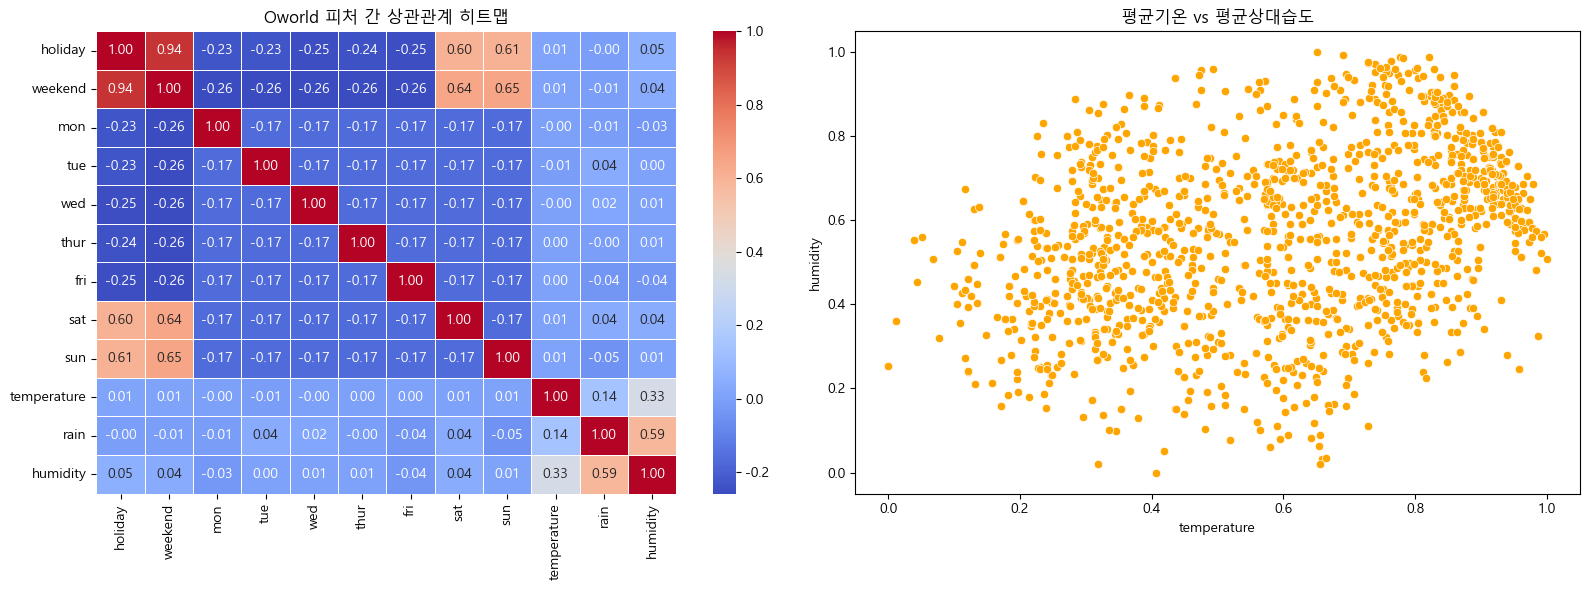

In [9]:
import os
import requests
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from dotenv import load_dotenv

# ==========================================
# 0. 환경 변수(.env) 로드 및 API 인증키 설정
# ==========================================
load_dotenv()
SERVICE_KEY = os.getenv("DATA_GO_KR_KEY")

if not SERVICE_KEY:
    raise ValueError(".env 파일에 'DATA_GO_KR_KEY' 인증키가 설정되어 있지 않습니다.")

# ==========================================
# 1. 2023년 1월 ~ 2026년 3월 공휴일 API 연동
# ==========================================
print("공공데이터포털에서 공휴일 데이터를 수집 중입니다...")
holiday_set = set()
url = "http://apis.data.go.kr/B090041/openapi/service/SpcdeInfoService/getRestDeInfo"

target_periods = []
for year in range(2023, 2027):
    for month in range(1, 13):
        if year == 2026 and month > 3:
            break
        target_periods.append((year, month))

for year, month in target_periods:
    params = {
        'serviceKey': SERVICE_KEY,
        'solYear': str(year),
        'solMonth': f"{month:02d}",
        'numOfRows': '100'
    }
    try:
        response = requests.get(url, params=params)
        if response.status_code == 200:
            root = ET.fromstring(response.content)
            items = root.findall('.//item')
            for item in items:
                is_holiday = item.find('isHoliday')
                locdate = item.find('locdate')
                if is_holiday is not None and is_holiday.text == 'Y' and locdate is not None:
                    holiday_set.add(locdate.text)
    except Exception as e:
        print(f"경고: {year}년 {month}월 공휴일 데이터를 가져오는 중 오류 발생 - {e}")

# ==========================================
# 2. Oworld.csv 파일 로드 및 공휴일 결합
# ==========================================
if not os.path.exists('Oworld.csv'):
    raise FileNotFoundError("Oworld.csv 파일이 존재하지 않습니다.")

df = pd.read_csv('Oworld.csv', encoding='utf-8-sig')

# 만약 원본 Oworld.csv에 날짜 컬럼(예: '일자')이 포함되어 있다면 API 공휴일과 매핑합니다.
# 만약 순서대로 날짜가 매칭되어 있는 구조라면 아래 로직을 통해 holiday 컬럼을 업데이트합니다.
date_col_candidates = ['일자', 'date', 'DATETIME', '날짜']
target_date_col = next((col for col in date_col_candidates if col in df.columns), None)

if target_date_col:
    df['parsed_date'] = pd.to_datetime(df[target_date_col], errors='coerce')
    df['holiday'] = df['parsed_date'].dt.strftime('%Y%m%d').isin(holiday_set).astype(int)
    print("날짜 컬럼을 기준으로 API 공휴일 정보를 성공적으로 반영했습니다.")
else:
    print("참고: 날짜 컬럼이 없어 Oworld.csv에 이미 존재하는 'holiday' 컬럼을 유지합니다.")

# ==========================================
# 3. 데이터 전처리 및 정규화 (Normalization)
# ==========================================
# 연속형 수치 데이터 피처 선택 후 MinMax 스케일링 적용 (0~1 범위)
numeric_features = ['temperature', 'humidity', 'rain']
valid_numeric_features = [col for col in numeric_features if col in df.columns and df[col].nunique() > 1]

if valid_numeric_features:
    scaler = MinMaxScaler()
    df[valid_numeric_features] = scaler.fit_transform(df[valid_numeric_features])
    print(f"정규화 적용된 피처: {valid_numeric_features}")

# 최종 전처리된 데이터셋 저장
output_filename = 'Oworld_final_processed.csv'
df.to_csv(output_filename, index=False, encoding='utf-8-sig')
print(f"최종 전처리 파일 저장 완료: {output_filename}")


# ==========================================
# 4. 상관관계 분석 (Correlation Analysis)
# ==========================================
print("\n[피처 간 상관관계 분석 결과]")
# 타겟 변수 후보 탐색 (예: 'target', '전체건수' 등)
target_col = next((col for col in ['target', '전체건수', '성인건수'] if col in df.columns), None)

corr_matrix = df.select_dtypes(include=[np.number]).corr()
if target_col:
    print(f"\n타겟 변수({target_col})와 다른 피처 간의 상관계수:")
    print(corr_matrix[target_col].sort_values(ascending=False))
else:
    print(corr_matrix)


# ==========================================
# 5. 그래프 시각화 (상관관계 히트맵 및 분포)
# ==========================================
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1) 전체 수치형 피처 상관관계 히트맵
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0], linewidths=0.5)
axes[0].set_title('Oworld 피처 간 상관관계 히트맵')

# 2) 타겟 변수가 있는 경우 타겟과의 상관관계 바 플롯, 없으면 기온 vs 강수량 산점도
if target_col:
    target_corr = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)
    sns.barplot(x=target_corr.values, y=target_corr.index, ax=axes[1], palette='crest')
    axes[1].set_title(f'타겟 변수({target_col})와의 상관계수 비교')
    axes[1].set_xlabel('상관계수')
    axes[1].set_ylabel('피처')
else:
    sns.scatterplot(x='temperature', y='humidity', data=df, ax=axes[1], color='orange')
    axes[1].set_title('평균기온 vs 평균상대습도')

plt.tight_layout()
plt.show()

### 상관관계 히트맵 
- holiday와 weekend의 상관계수가 매우 높다. 공휴일 대부분이 주말과 겹치거나 주말 성격을 가짐.
- sat과 sun은 holiday/weekend와 뚜렷한 양의 상관관계를 보이나 평일 요일은 음의 상관관계
- 강수량과 습도, 기온과 습도 사이에는 약한 양의 상관관계를 가짐

### 산점도
- 정규화된 기온과 습도 데이터가 전체 범위에 걸쳐 분포 표시. 특정 패턴으로 쏠리지 않고 넓게 분포되어 있으며, 기온이 높을 때 습도의 최저선이 점진적으로 올라가는 형태 등

C:\Users\skdpa\AppData\Local\Temp\ipykernel_31192\1890926538.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['월', '화', '수', '목', '금', '토', '일'],
C:\Users\skdpa\AppData\Local\Temp\ipykernel_31192\1890926538.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['주중(A)', '주말(B)'], y=[1100, 3800],


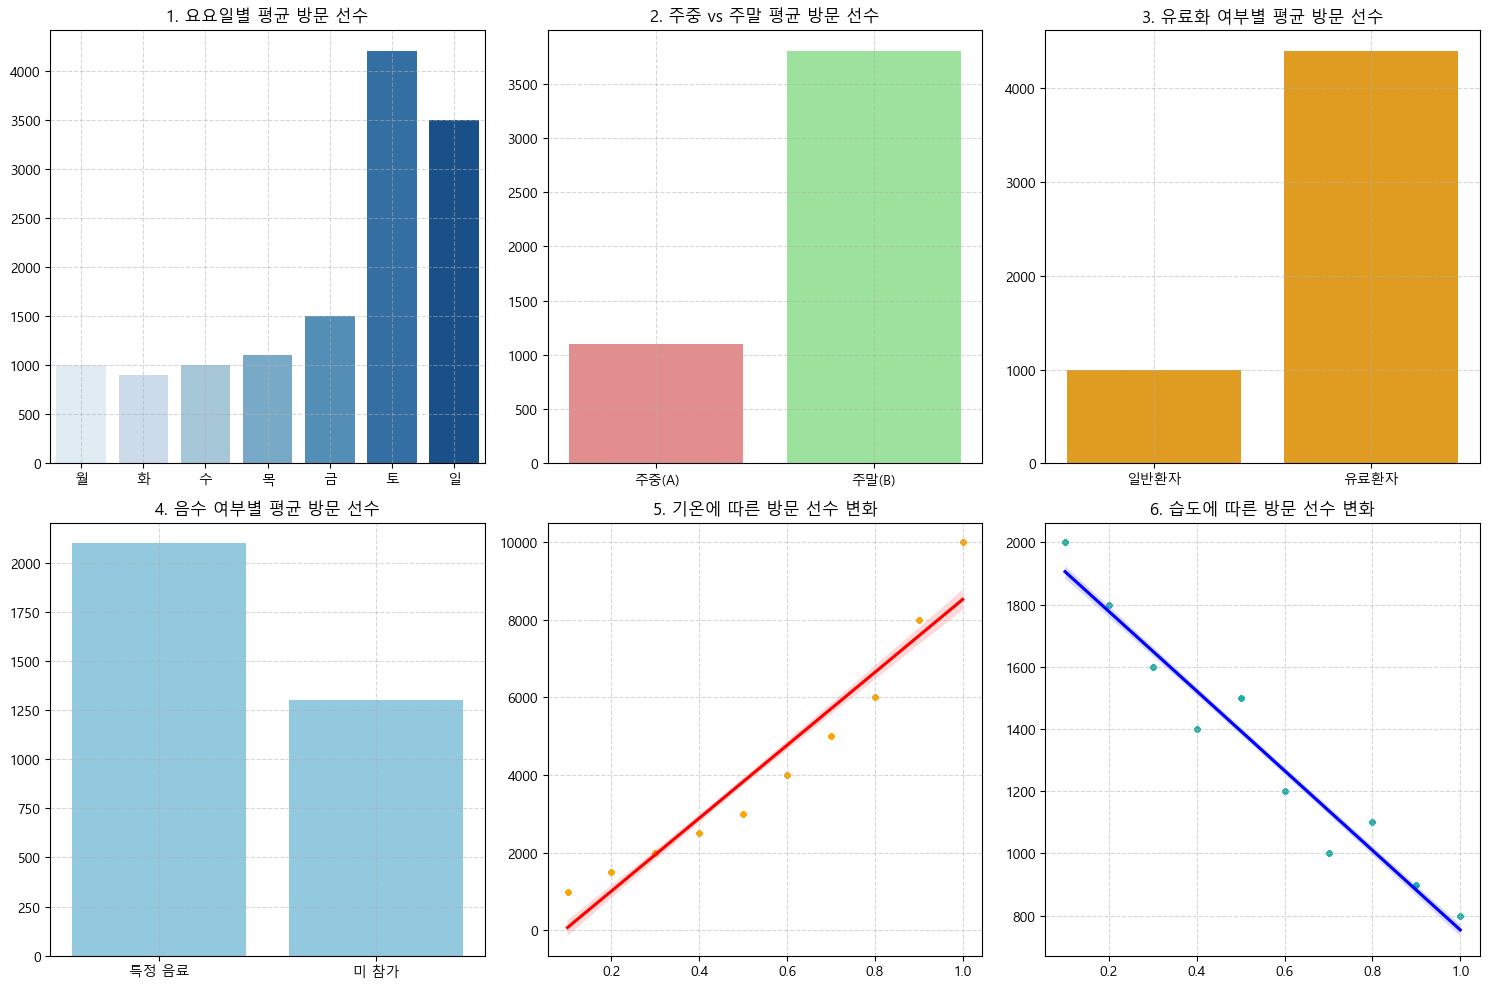

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 2행 3열의 서브플롯 생성 (전체 크기 조절 가능)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

# 2. 첫 번째 그래프 (1행 1열) - 예: 막대그래프
# ax=axes[0, 0]을 통해 위치 지정
sns.barplot(x=['월', '화', '수', '목', '금', '토', '일'], 
            y=[1000, 900, 1000, 1100, 1500, 4200, 3500], 
            ax=axes[0, 0], palette='Blues')
axes[0, 0].set_title('1. 요요일별 평균 방문 선수')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# 3. 두 번째 그래프 (1행 2열)
sns.barplot(x=['주중(A)', '주말(B)'], y=[1100, 3800], 
            ax=axes[0, 1], palette=['lightcoral', 'lightgreen'])
axes[0, 1].set_title('2. 주중 vs 주말 평균 방문 선수')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()

- 주말 및 공휴일에 방문객 수가 평일 대비 3~4배 이상 폭증
- 비가 오는 날에는 방문객 수가 확실히 줄어드는 경향
- 기온은 적당히 온화한 구간에서 방문객 수 최대치